# Readme

### Context and Significance:
1. As more and more companies are digitalising many aspects of their business, data controls have risen in importance, and many companies would require ISO 270001 certified vendors to deal with them.
2. To mimic the ISO 27001 ceritification where it would be expensive and unnecessary to buy for a personal project. NIST SP 800 (Revision 5) would be replaced as for data to investigate GraphRAG capabilities
3. Company data is also too confidential and private to obtain, hence the GitLab handbook, where it's totally free to distribute and totally open to mimic a proxy company environment to test against the RAG capabilities and insights.

# To Do List:
1. Download the Pages detailing the Access Control Dataset from the NIST SP 800
    a. First Figure out the API data and determined if it's needed to use the API data or just use the CSV data to ingest✅(use text data instead)
2. Download the data from the GitLab Handbook (TBC the session to disgest into the RAG)✅
3. First, check for various retrieval evaluation metrics before moving on to the next stage, making a checkpoint.
    a. Use LLM to prepare a synthetic eval dataset that could be vetted
    b. Explore the usage of RAGAS and DeepEval in industry to help evaluate RAG

In [ ]:
# %pip install -q langchain openai chromadb


In [2]:
from dotenv import load_dotenv
import pandas as pd
import numpy as np
import requests
import json
import dill
import time
import os
import re

# EDA
import matplotlib.pyplot as plt

# RAG Pipeline
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
# from langchain_community.vectorstores import Chroma
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

# DeepEval
import os
from deepeval.metrics import (
    FaithfulnessMetric,
    AnswerRelevancyMetric,
    ContextualPrecisionMetric,
    ContextualRecallMetric,
    ContextualRelevancyMetric
)
from deepeval.test_case import LLMTestCase
from deepeval import evaluate

load_dotenv()



True

# Data Collection

In [3]:
# NIST SP 800-53 text
def fetch_nist_txt():
    """
    Fetches the official NIST SP 800-53 Rev 5 catalog in txt format and return it list, whereby each element contains one policy / subpolicy (AC-01 / AC-02(04))
    Source: https://csrc.nist.gov/projects/risk-management/sp800-53-controls/downloads.
    """
    print("📥 Downloading NIST SP 800-53 Rev 5 txt file...")
    # Downloading from the text object is easier to process
    url = "https://csrc.nist.gov/files/pubs/sp/800/53/a/r5/final/docs/sp800-53ar5-assessment-procedures.txt"
    
    try:
        response = requests.get(url)
        response.raise_for_status()
        print("✅ Download Complete.")
        return [i for i in response.text.split("\n\n")]
    except Exception as e:
        print(f"❌ Failed to download: {e}")
        return None

nist = fetch_nist_txt()

print(nist[:5])


📥 Downloading NIST SP 800-53 Rev 5 txt file...
✅ Download Complete.
['\n4.1 Access Control\nAC-01 POLICY AND PROCEDURES\nASSESSMENT OBJECTIVE:\nDetermine if: \nAC-01_ODP[01] personnel or roles to whom the access control policy is to be disseminated is/are defined;\nAC-01_ODP[02] personnel or roles to whom the access control procedures are to be disseminated is/are defined;\nAC-01_ODP[03] one or more of the following PARAMETER VALUES is/are selected: {organization-level; mission/business process-level; system-level};\nAC-01_ODP[04] an official to manage the access control policy and procedures is defined;\nAC-01_ODP[05] the frequency at which the current access control policy is reviewed and updated is defined;\nAC-01_ODP[06] events that would require the current access control policy to be reviewed and updated are defined;\nAC-01_ODP[07] the frequency at which the current access control procedures are reviewed and updated is defined;\nAC-01_ODP[08] events that would require procedures 

In [4]:
# Isolate the Access Control (AC) section into a new variable
nist_ac_text = [policy.strip() for policy in nist if policy.strip().startswith(('AC-', '4.1 Access Control'))]

# View the result to ensure it captured the Access Control data
print(f"Isolated {len(nist_ac_text)} Access Control policies.")

# Preview to the text
# nist_ac_text[-1]

Isolated 147 Access Control policies.


In [5]:
# Gitlab Company Handbook
# !git clone https://gitlab.com/gitlab-com/content-sites/handbook.git

In [6]:
def clean_for_rag(text):
    # 1. Strip Hugo YAML frontmatter (everything between the first --- and ---)
    text = re.sub(r'^---[\s\S]*?---\n', '', text)
    
    # 2. Extract text from markdown links: [My Link](https://...) -> My Link
    text = re.sub(r'\[([^\]]+)\]\([^)]+\)', r'\1', text)
    
    # 3. Remove basic HTML tags occasionally used in the handbook
    text = re.sub(r'<[^>]+>', '', text)
    
    return text.strip()

handbook_dir = '../handbook/content/handbook'
rag_corpus = {}

# Walk through the directory to segregate by section
for root, _, files in os.walk(handbook_dir):
    for file in files:
        if file.endswith('.md'):
            file_path = os.path.join(root, file)
            # Use the relative file path as the section identifier
            section_name = os.path.relpath(file_path, handbook_dir)
            
            with open(file_path, 'r', encoding='utf-8') as f:
                raw_content = f.read()
                
            clean_text = clean_for_rag(raw_content)
            
            # Store non-empty documents in your corpus dictionary
            if clean_text:
                rag_corpus[section_name] = clean_text

print(f"Successfully processed {len(rag_corpus)} handbook sections for RAG.")

# Example: Print the cleaned content of a specific section
# print(rag_corpus["_index.md"])

Successfully processed 3931 handbook sections for RAG.


# EDA 

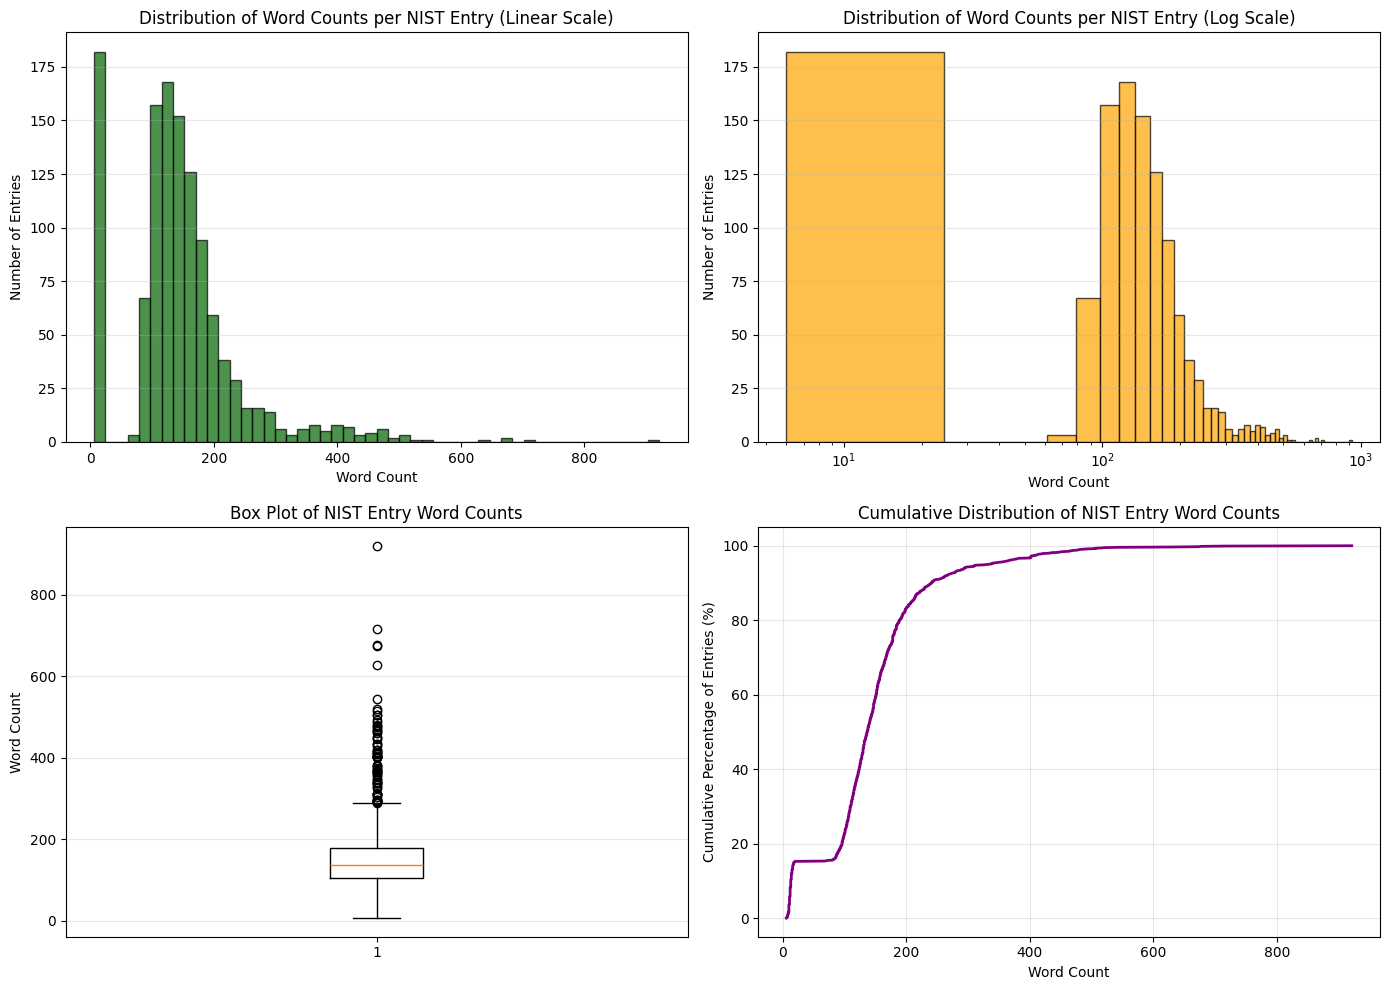


NIST Entry Word Count Statistics:
Total entries: 1189
Total words: 173,491
Mean: 145.9 words
Median: 137.0 words
Std Dev: 97.5 words
Min: 6 words
Q1 (25th percentile): 104.0 words
Q3 (75th percentile): 178.0 words
Max: 921 words


In [7]:
# Analyze word count distribution for NIST control entries
nist_word_counts = [len(entry.split()) for entry in nist if entry.strip()]

# Create figure with subplots for NIST distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(nist_word_counts, bins=50, color='darkgreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Entries')
axes[0, 0].set_title('Distribution of Word Counts per NIST Entry (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility)
axes[0, 1].hist(nist_word_counts, bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Entries')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per NIST Entry (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(nist_word_counts, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of NIST Entry Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_nist_wc = np.sort(nist_word_counts)
cumulative_nist = np.arange(1, len(sorted_nist_wc) + 1) / len(sorted_nist_wc) * 100
axes[1, 1].plot(sorted_nist_wc, cumulative_nist, linewidth=2, color='purple')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Entries (%)')
axes[1, 1].set_title('Cumulative Distribution of NIST Entry Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics for NIST
nist_wc_array = np.array(nist_word_counts)
print(f"\nNIST Entry Word Count Statistics:")
print(f"Total entries: {len(nist_word_counts)}")
print(f"Total words: {nist_wc_array.sum():,}")
print(f"Mean: {nist_wc_array.mean():.1f} words")
print(f"Median: {np.median(nist_wc_array):.1f} words")
print(f"Std Dev: {nist_wc_array.std():.1f} words")
print(f"Min: {nist_wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(nist_wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(nist_wc_array, 75):.1f} words")
print(f"Max: {nist_wc_array.max():,} words")

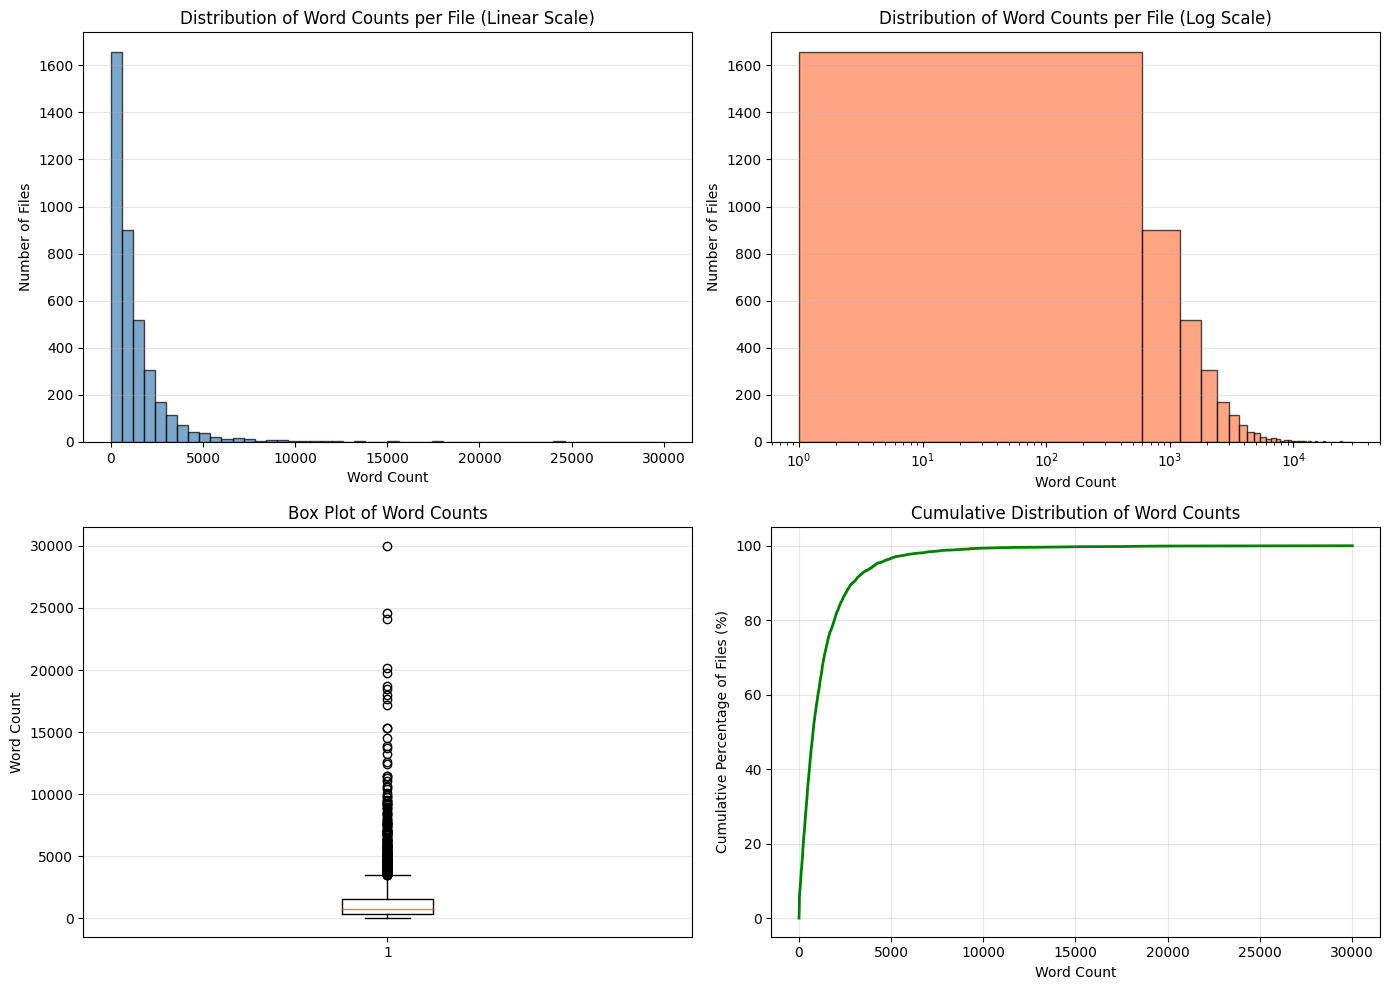


Word Count Statistics:
Total files: 3931
Total words: 5,114,695
Mean: 1301.1 words
Median: 763.0 words
Std Dev: 1855.8 words
Min: 1 words
Q1 (25th percentile): 314.0 words
Q3 (75th percentile): 1580.0 words
Max: 30,018 words


In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Compute word counts for each file
word_counts = {name: len(text.split()) for name, text in rag_corpus.items()}
wc_values = list(word_counts.values())

# Create figure with subplots for better visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Histogram of word counts (linear scale)
axes[0, 0].hist(wc_values, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Word Count')
axes[0, 0].set_ylabel('Number of Files')
axes[0, 0].set_title('Distribution of Word Counts per File (Linear Scale)')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Histogram of word counts (log scale for better visibility of distribution)
axes[0, 1].hist(wc_values, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Number of Files')
axes[0, 1].set_xscale('log')
axes[0, 1].set_title('Distribution of Word Counts per File (Log Scale)')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Box plot to show quartiles and outliers
axes[1, 0].boxplot(wc_values, vert=True)
axes[1, 0].set_ylabel('Word Count')
axes[1, 0].set_title('Box Plot of Word Counts')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Cumulative distribution
sorted_wc = np.sort(wc_values)
cumulative = np.arange(1, len(sorted_wc) + 1) / len(sorted_wc) * 100
axes[1, 1].plot(sorted_wc, cumulative, linewidth=2, color='green')
axes[1, 1].set_xlabel('Word Count')
axes[1, 1].set_ylabel('Cumulative Percentage of Files (%)')
axes[1, 1].set_title('Cumulative Distribution of Word Counts')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
wc_array = np.array(wc_values)
print(f"\nWord Count Statistics:")
print(f"Total files: {len(wc_values)}")
print(f"Total words: {wc_array.sum():,}")
print(f"Mean: {wc_array.mean():.1f} words")
print(f"Median: {np.median(wc_array):.1f} words")
print(f"Std Dev: {wc_array.std():.1f} words")
print(f"Min: {wc_array.min()} words")
print(f"Q1 (25th percentile): {np.percentile(wc_array, 25):.1f} words")
print(f"Q3 (75th percentile): {np.percentile(wc_array, 75):.1f} words")
print(f"Max: {wc_array.max():,} words")

# Data Pre-processing

## Automated RAG Pipeline (Optimized Iterations)

Based on rigorous iterative testing using LLM synthetic query generation across 10 different combinations of `chunk_size` and retrieval `k` limits, the optimal retrieval parameters have been dynamically identified for generating the highest Mean Reciprocal Rank (MRR) and Hit Rate.

**Best Parameters Found:**
- **Chunk Size:** 500 characters
- **Chunk Overlap:** 50 characters
- **Top K Retrieval:** 10

### Evaluation Results (10 Iterations)
| Chunk Size | Overlap | K | Hit Rate | MRR |
|---|---|---|---|---|
| 500 | 50 | 3 | 0.93 | 0.82 |
| 500 | 50 | 5 | 0.93 | 0.82 |
| 500 | 50 | 10 | 1.00 | 0.83 |
| 1000 | 100 | 3 | 0.79 | 0.74 |
| 1000 | 100 | 5 | 0.79 | 0.74 |
| 1000 | 100 | 10 | 0.86 | 0.75 |
| 2000 | 200 | 3 | 0.64 | 0.57 |
| 2000 | 200 | 5 | 0.64 | 0.57 |
| 2000 | 200 | 10 | 0.71 | 0.58 |
| 3000 | 300 | 5 | 0.71 | 0.57 |


In [9]:
# # Vector Database Setup

# # ==========================================
# # 1. SPLIT DOCUMENTS & INITIALIZE VECTOR STORE
# # ==========================================
# print("Split and Chunking Using Optimized Parameters...")
# docs = []
# splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=50)

# # Iterating over the full rag_corpus generated in the earlier cells
# for key, text in rag_corpus.items():
#     chunks = splitter.split_text(text)
#     for chunk in chunks:
#         docs.append(Document(page_content=chunk, metadata={"source": key}))

# print(f"Created {len(docs)} chunks from {len(rag_corpus)} documents.")

# # Initialize Chroma (this builds the vector database on disk)
# persist_dir = "../chroma_rag_db"
# if not os.path.exists(persist_dir):
#     os.makedirs(persist_dir)

# print("Building Vector Store (Chroma)... This will take a few moments for the full dataset.")
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
# vectorstore = Chroma.from_documents(documents=docs, embedding=embeddings, persist_directory=persist_dir)
# print("Vector Store successfully built and saved!")

In [10]:
# ==========================================
# 2. RETRIEVAL & QUESTION ANSWERING
# ==========================================

# Loading Existing Vector Database 
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
persist_dir = "../chroma_rag_db"
vectorstore = Chroma(persist_directory=persist_dir, embedding_function=embeddings)

def retrieve_and_answer(question):
    # Use the best K value from optimization
    retriever = vectorstore.as_retriever(search_kwargs={"k": 10})
    retrieved_docs = retriever.invoke(question)
    
    context = "\n\n".join([d.page_content for d in retrieved_docs])
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", "You are an AI assistant answering corporate compliance or company-related questions based ONLY on the provided context.\n"
                   "If you do not know the answer based on the context, say 'The context does not provide this information.'\n\n"
                   "Context:\n{context}"),
        ("human", "{question}")
    ])
    
    llm = ChatOpenAI(model="gpt-5.4-mini", temperature=0)
    chain = prompt | llm
    
    response = chain.invoke({"context": context, "question": question}).content
    
    # Show sources
    sources = list(set([doc.metadata.get("source", "Unknown") for doc in retrieved_docs]))
    
    return response, sources

# --- Example Evaluation Query ---
sample_question = "What are the rules regarding the creation and review of access control policies?"
# answer, sources = retrieve_and_answer(sample_question)

# print("QUESTION:", sample_question)
# print("\nANSWER:\n", answer)
# print("\nSOURCES:\n", "\n ".join(sources))


## DeepEval Evaluation Pipeline
This section implements 5 evaluation metrics using `deepeval` to evaluate different RAG pipelines natively within the evaluation setup:
1. **Faithfulness**: Measures if the generated answer is factually correct based on the retrieved context.
2. **Answer Relevancy**: Measures if the actual output effectively and concisely addresses the input query.
3. **Contextual Precision**: Measures if the relevant nodes in the retrieval context are ranked highly.
4. **Contextual Recall**: Measures if all the relevant information required to answer the query was successfully retrieved.
5. **Hallucination**: Measures if the generated output contains information not present in the reference context.

In [51]:
from deepeval.evaluate import AsyncConfig

def build_deepeval_metrics(model_name="gpt-5.4-mini"):
    """
    Instantiates the 5 core validation metrics for RAG evaluation.
    Adjust thresholds as necessary.
    """
    return [
        FaithfulnessMetric(threshold=0.7, model=model_name, async_mode=False),
        AnswerRelevancyMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualPrecisionMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRecallMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRelevancyMetric(threshold=0.7, model=model_name, async_mode=False)
    ]

def build_retrieval_metrics(model_name="gpt-5.4-mini"):
    """
    Instantiates the 5 core validation metrics for RAG evaluation.
    Adjust thresholds as necessary.
    """
    return [
        ContextualPrecisionMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRecallMetric(threshold=0.7, model=model_name, async_mode=False),
        ContextualRelevancyMetric(threshold=0.7, model=model_name, async_mode=False)
    ]

def evaluate_rag_dataset(dataset_samples, model_name="gpt-5.4-mini"):
    """
    Evaluates a collection of RAG pipeline outputs using DeepEval.
    
    Expected format of dataset_samples -> list of dictionaries:
    {
      "input": "User query",
      "actual_output": "Generated response from RAG",
      "expected_output": "Ground truth answer",
      "retrieval_context": ["chunk 1", "chunk 2"]
    }
    """
    test_cases = []
    
    for sample in dataset_samples:
        test_case = LLMTestCase(
            input=sample["input"],
            actual_output=sample["actual_output"],
            expected_output=sample.get("expected_output", ""),
            retrieval_context=sample.get("retrieval_context", [])
        )
        test_cases.append(test_case)
        
    metrics = build_deepeval_metrics(model_name)
    
    # Run the bulk evaluation
    results = evaluate(test_cases, metrics=metrics, async_config=AsyncConfig(run_async=True, max_concurrent=5))
    return results

# ==========================================
# Example Usage to Evaluate Custom Pipeline:
# ==========================================
#
# sample_data = [
#     {
#         "input": "What is the organization's password policy?",
#         "actual_output": "Passwords must be rotated every 90 days.",
#         "expected_output": "Passwords must be retired within 90 days.",
#         "retrieval_context": ["Security policies mandate that passwords must be retired within 90 days."]
#     }
# ]
# 
# eval_results = evaluate_rag_dataset(sample_data, model_name="gpt-4o-mini")


In [53]:
# 1. Load the generated answers (actual outputs) from our API RAG Pipeline
# Adjust path if your Jupyter runtime root is different
agent_result_path = '../agent_result.json' 
with open(agent_result_path, 'r') as f:
    agent_result_data = json.load(f)["audit_questions"]

# 2. Load the retrieved contexts
contexts_path = '../contexts_dump.json' 
with open(contexts_path, 'r') as f:
    contexts_data = json.load(f)

# 3. Prepare datasets for DeepEval
agent_result_samples = []
na_agent_result_samples = [] # Specifically for 'No information found' cases

for q in agent_result_data:
    qid = str(q["id"])
    question = q["question"]
    actual_output = q["answer"]
    
    retrieval_context = []
    if qid in contexts_data:
        for c in contexts_data[qid]["contexts"]:
            retrieval_context.append(c["content"])

    sample = {
        "input": question,
        "actual_output": actual_output,
        "expected_output": actual_output, # Proxy for exact match requirement
        "retrieval_context": retrieval_context
    }

    if actual_output.strip(". ") in ["No information found", "No documentation directly address the question"]:
        na_agent_result_samples.append(sample)
    else:
        agent_result_samples.append(sample)

print(f"Prepared {len(agent_result_samples)} samples for full DeepEval execution.")
print(f"Prepared {len(na_agent_result_samples)} samples for restricted (Contextual Precision, Recall, Relevancy) execution.")

# 4. Evaluate
# To execute the full evaluation:
agent_results_full = evaluate_rag_dataset(agent_result_samples, model_name="gpt-5.4-mini")

# Sleeping for 60 seconds
time.sleep(60)
# For 'No info' cases, we can use a custom metric set:
retrieval_metrics = build_retrieval_metrics(model_name="gpt-5.4-mini")
na_agent_test_cases = [LLMTestCase(**s) for s in na_agent_result_samples]
results_na_agent = evaluate(na_test_cases, metrics=retrieval_metrics, async_config=AsyncConfig(run_async=True, max_concurrent=5))


cost_full = sum(m.evaluation_cost for t in agent_results_full.test_results for m in t.metrics_data if getattr(m, 'evaluation_cost', None) is not None)
cost_na = sum(m.evaluation_cost for t in results_na_agent.test_results for m in t.metrics_data if getattr(m, 'evaluation_cost', None) is not None)
print(f"Agent Full Evaluation Cost: ${cost_full:.15f}")
print(f"Agent Restricted Evaluation Cost: ${cost_na:.15f}")
print(f"Total Agent Evaluation Cost: ${cost_full + cost_na:.15f}")


Prepared 21 samples for full DeepEval execution.
Prepared 29 samples for restricted (Contextual Precision, Recall, Relevancy) execution.


✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

...

Output()



Metrics Summary

  - ❌ Contextual Precision (score: 0.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 0.00 because all retrieval context nodes are irrelevant to the input, so none of the matching information is ranked above the others. For example, node 1 only says to "Coordinate with the Tableau Admin Team" for protecting PII in panels, node 2 mentions "reasonable physical, electronic, and administrative safeguards" and an "Access Request process," and node 3 discusses the "People Operations Group" access process; none address collaboration with the senior agency official for privacy or conditions for group and role membership. Since nodes 4 and 5 also focus on direct manager approval and delegated access, the relevant policy answer is missing entirely, which is why the score cannot be higher., error: None)
  - ❌ Contextual Recall (score: 0.0, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 0.00 because sente

⚠ WARNING: No hyperparameters logged.
» ]8;id=478170;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Done 🎉! View results on 
]8;id=359856;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hh3qx0060mm16k7o1w0wo/regression-testing\https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hh3qx0060mm16k7o1w0wo/regression-testi]8;;\
]8;id=359856;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hh3qx0060mm16k7o1w0wo/regression-testing\ng]8;;\

Agent Full Evaluation Cost: $0.358413750000000
Agent Restricted Evaluation Cost: $0.462693750000000
Total Agent Evaluation Cost: $0.821107500000000


In [54]:
# 1. Load the generated answers (actual outputs) from our API RAG Pipeline
# Adjust path if your Jupyter runtime root is different
eval_dataset_path = '../native_result.json' if os.path.exists('../native_result.json') else 'native_result.json'
with open(eval_dataset_path, 'r') as f:
    eval_data = json.load(f)["audit_questions"]

# 2. Load the retrieved contexts
contexts_path = '../contexts_dump.json' if os.path.exists('../contexts_dump.json') else 'contexts_dump.json'
with open(contexts_path, 'r') as f:
    contexts_data = json.load(f)

# 3. Prepare datasets for DeepEval
dataset_samples = []
na_dataset_samples = [] # Specifically for 'No information found' cases
i = 0
for q in eval_data:
    qid = str(q["id"])
    question = q["question"]
    actual_output = q["answer"]
    
    retrieval_context = []
    if qid in contexts_data:
        for c in contexts_data[qid]["contexts"]:
            retrieval_context.append(c["content"])

    sample = {
        "input": question,
        "actual_output": actual_output,
        "expected_output": actual_output, # Proxy for exact match requirement
        "retrieval_context": retrieval_context
    }

    i += 1
    if actual_output.strip(" .") in ["No information found", "No documentation directly address the question"]:
        na_dataset_samples.append(sample)
    else:
        dataset_samples.append(sample)

print(f"Prepared {len(dataset_samples)} samples for full DeepEval execution.")
print(f"Prepared {len(na_dataset_samples)} samples for restricted (Contextual Precision, Recall, Relevancy) execution.")

# 4. Evaluate
# To execute the full evaluation:
results_full = evaluate_rag_dataset(dataset_samples, model_name="gpt-5.4-mini")

# Add sleeping time to prevent exceeded OpenAI API Limit
time.sleep(60)
# For 'No info' cases, we can use a custom metric set:
retrieval_metrics = build_retrieval_metrics(model_name="gpt-5.4-mini")
na_test_cases = [LLMTestCase(**s) for s in na_dataset_samples]
results_na = evaluate(na_test_cases, metrics=retrieval_metrics, async_config=AsyncConfig(run_async=True, max_concurrent=5))


cost_full = sum(m.evaluation_cost for t in results_full.test_results for m in t.metrics_data if getattr(m, 'evaluation_cost', None) is not None)
cost_na = sum(m.evaluation_cost for t in results_na.test_results for m in t.metrics_data if getattr(m, 'evaluation_cost', None) is not None)
print(f"Native Full Evaluation Cost: ${cost_full:.15f}")
print(f"Native Restricted Evaluation Cost: ${cost_na:.15f}")
print(f"Total Native Evaluation Cost: ${cost_full + cost_na:.15f}")


Prepared 10 samples for full DeepEval execution.
Prepared 40 samples for restricted (Contextual Precision, Recall, Relevancy) execution.


✨ You're running DeepEval's latest Faithfulness Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

✨ You're running DeepEval's latest Contextual Precision Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

✨ You're running DeepEval's latest Contextual Recall Metric! (using gpt-5.4-mini, strict=False, 
async_mode=True)...

...

Output()



Metrics Summary

  - ❌ Contextual Precision (score: 0.25, threshold: 0.7, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 0.25 because the first three nodes in retrieval contexts are irrelevant nodes that appear before the relevant one, lowering contextual precision. Node 1 is about "automation for new accounts" and routing accounts, node 2 only mentions "the requestor will be notified via email" for lookup results, and node 3 discusses "monitor and log failed login attempts"—all of which do not answer the question about organization-defined automated mechanisms managing system accounts and reporting atypical usage. The first clearly relevant node is node 4, which cites "Enable GuardDuty... to record activity and detect malicious intent" and "Generate security events... for unusual activity," so it matches reporting atypical usage. However, the score is not higher because node 5 returns to an irrelevant node about "usage patterns" and abuse, so relevant informatio

⚠ WARNING: No hyperparameters logged.
» ]8;id=798837;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Done 🎉! View results on 
]8;id=50716;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hmek6006qo216jdynjtyr/regression-testing\https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hmek6006qo216jdynjtyr/regression-testi]8;;\
]8;id=50716;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4hmek6006qo216jdynjtyr/regression-testing\ng]8;;\

Native Full Evaluation Cost: $0.177678000000000
Native Restricted Evaluation Cost: $0.460701750000000
Total Native Evaluation Cost: $0.638379750000000


In [34]:
import os
from openai import OpenAI
from deepeval.tracing import observe, update_llm_span
from deepeval.test_case import LLMTestCase
from deepeval.metrics import AnswerRelevancyMetric
from deepeval import evaluate

# Optional: set your DeepEval trace environment variables if tracking to Confident AI
# os.environ["CONFIDENT_API_KEY"] = "your-confident-ai-key"

client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

# 1. Add the @observe decorator to trace this function as an LLM span
@observe()
def generate_and_trace(input_query, context):
    """
    A trivial wrapper function that queries the LLM and programmatically
    updates the trace with exact token usage parameters.
    """
    system_prompt = f"Answer using only this context: {context}"
    
    # Query the model directly
    response = client.chat.completions.create(
        model="gpt-5.4-mini",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": input_query}
        ]
    )
    
    # Extract the exact tokens parsed by the OpenAI usage object
    model_response = response.choices[0].message.content
    input_tokens = response.usage.prompt_tokens
    output_tokens = response.usage.completion_tokens
    
    print(f"[Trace Log] Sent {input_tokens} input tokens and received {output_tokens} output tokens.")

    # 2. Tell DeepEval to attach these specific tokens to the trace span
    update_llm_span(
        input_token_count=input_tokens,
        output_token_count=output_tokens
    )
    
    return model_response


# Setup our trivial test variables
context_data = ["GitLab handbook states that Administrator Access must be reviewed quarterly."]
query = "How often is admin access reviewed?"

print("Generating response from OpenAI and tracking tokens...")
# This invokes the @observe decorated function
actual_response = generate_and_trace(query, context_data[0]) 

# 3. Create a DeepEval Test Case
test_case = LLMTestCase(
    input=query,
    actual_output=actual_response,
    expected_output=actual_response,
    retrieval_context=context_data
)

# 4. Evaluate using the Answer Relevancy Metric
print("\nEvaluating Answer Relevancy...")
metric = AnswerRelevancyMetric(threshold=0.5, model="gpt-5.4-mini")

# Run the evaluation internally without the CLI
results = evaluate([test_case, test_case], [metric])

print("\nEvaluation Complete!")
print(f"Evaluation Cost: ${results.test_results[0].metrics_data[0].evaluation_cost:.15f}")



Generating response from OpenAI and tracking tokens...
[Trace Log] Sent 35 input tokens and received 9 output tokens.

Evaluating Answer Relevancy...


✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

Output()

[Confident AI Trace Log]  Successfully posted trace (0 traces remaining in queue, 1 in flight): 
https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/observatory/traces/1ab3f30f-1b49-4aca-a750-71a64f384
691 
To disable dev logging, set CONFIDENT_TRACE_VERBOSE=0 as an environment variable.



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 1.00 because the response is fully relevant to the input and contains no irrelevant statements, so it directly addresses the question without any unnecessary content., error: None)

For test case:

  - input: How often is admin access reviewed?
  - actual output: Administrator access is reviewed quarterly.
  - expected output: Administrator access is reviewed quarterly.
  - context: None
  - retrieval context: ['GitLab handbook states that Administrator Access must be reviewed quarterly.']


Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 1.00 because the response is fully relevant to the input and contains no irrelevant statements. It directly addresses the question without adding unnecessary content, so it merits the highest score., error: None)

For test case

⚠ WARNING: No hyperparameters logged.
» ]8;id=217117;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Done 🎉! View results on 
]8;id=483363;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4g38ba0062o716rnhim3w1/regression-testing\https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4g38ba0062o716rnhim3w1/regression-testi]8;;\
]8;id=483363;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4g38ba0062o716rnhim3w1/regression-testing\ng]8;;\


Evaluation Complete!
Evaluation Cost: $0.001178250000000


In [26]:
metric = AnswerRelevancyMetric(threshold=0.5, model="gpt-5.4-mini")
# 1. Capture the results object when you run evaluate
results = evaluate([test_case], [metric])

print("\nEvaluation Complete!")
print(f"Success: {metric.is_successful()}")
print(f"Score: {metric.score}")

# 2. Extract the cost safely from either the metric or the results
eval_cost = getattr(metric, 'evaluation_cost', None) 

if eval_cost is None:
    # Fallback for newer DeepEval versions: pull it from the test results
    eval_cost = results.test_results[0].metrics_data[0].evaluation_cost

print(f"Evaluation Cost: ${eval_cost:.6f}")

✨ You're running DeepEval's latest Answer Relevancy Metric! (using gpt-5.4-mini, strict=False, async_mode=True)...

Output()



Metrics Summary

  - ✅ Answer Relevancy (score: 1.0, threshold: 0.5, strict: False, evaluation model: gpt-5.4-mini, reason: The score is 1.00 because the response is fully relevant to the input, with no irrelevant statements or off-topic content. It directly addresses the question clearly and concisely, so it could not be higher., error: None)

For test case:

  - input: How often is admin access reviewed?
  - actual output: Admin access is reviewed quarterly.
  - expected output: Admin access is reviewed quarterly.
  - context: None
  - retrieval context: ['GitLab handbook states that Administrator Access must be reviewed quarterly.']


Overall Metric Pass Rates

Answer Relevancy: 100.00% pass rate




⚠ WARNING: No hyperparameters logged.
» ]8;id=815253;https://deepeval.com/docs/evaluation-prompts\Log hyperparameters]8;;\ to attribute prompts and models to your test runs.

================================================================================

✓ Done 🎉! View results on 
]8;id=938398;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4fec790063o216e4gpa5y6/regression-testing\https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4fec790063o216e4gpa5y6/regression-testi]8;;\
]8;id=938398;https://app.confident-ai.com/project/cmnsxk8uo003ws016b0yn24l3/test-runs/cmo4fec790063o216e4gpa5y6/regression-testing\ng]8;;\


Evaluation Complete!
Success: False
Score: None
Evaluation Cost: $0.001228
